# KV Cache & Inference Math

**Problem it solves:** to write token 501, attention needs the Keys and Values of tokens 1–500. Those were already computed one step ago. Recomputing them every step makes generation slower and slower as the answer grows.

**How it works:** keep the past Keys and Values in memory and append to them. Trade memory for compute.

**When it matters:** always, in production. The KV cache decides how many users fit on one GPU, how long your context can be, and what your bill looks like. This notebook is the arithmetic behind [3_llm_inference.md](../3_llm_inference.md).

NumPy only. We build a tiny decoder-only model, generate with and without a cache, prove the outputs are identical, then measure the difference.

## Step 1 — A tiny decoder-only model

Small enough to read in one screen, real enough to behave like the real thing: token embedding + position, one causal attention head, one MLP, then a projection back to the vocabulary.

The weights are random, so the generated "text" is nonsense. That is fine — we are measuring **how the work grows**, not what it says.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

VOCAB, D_MODEL, MAX_POS = 256, 128, 1024


def make_model():
    scale = 0.08
    return {
        "emb":  rng.normal(size=(VOCAB, D_MODEL)) * scale,
        "pos":  rng.normal(size=(MAX_POS, D_MODEL)) * scale,
        "W_q":  rng.normal(size=(D_MODEL, D_MODEL)) * scale,
        "W_k":  rng.normal(size=(D_MODEL, D_MODEL)) * scale,
        "W_v":  rng.normal(size=(D_MODEL, D_MODEL)) * scale,
        "W_o":  rng.normal(size=(D_MODEL, D_MODEL)) * scale,
        "W_1":  rng.normal(size=(D_MODEL, D_MODEL * 4)) * scale,
        "W_2":  rng.normal(size=(D_MODEL * 4, D_MODEL)) * scale,
        "head": rng.normal(size=(D_MODEL, VOCAB)) * scale,
    }


def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / np.sum(e, axis=axis, keepdims=True)


def mlp(x, m):
    hidden = np.maximum(0, x @ m["W_1"])      # ReLU
    return hidden @ m["W_2"]


model = make_model()
print("toy model ready:", sum(v.size for v in model.values()) / 1e6, "M parameters")

toy model ready: 0.393216 M parameters


## Step 2 — Generating **without** a cache (the slow way)

Every step re-runs the whole sequence from token 1. Step 1 processes 1 token, step 2 processes 2, step 50 processes 50. Add that up and the total work is O(n²).

`work_positions` counts how many token-positions the model touched in total. That is the honest measure — it does not depend on how fast your laptop is.

In [2]:
def forward_full(tokens, m):
    '''Run the whole sequence through the model. Returns logits for every position.'''
    n = len(tokens)
    x = m["emb"][tokens] + m["pos"][:n]        # token meaning + position

    Q, K, V = x @ m["W_q"], x @ m["W_k"], x @ m["W_v"]
    scores = Q @ K.T / np.sqrt(D_MODEL)
    scores = np.where(np.tril(np.ones((n, n), dtype=bool)), scores, -np.inf)
    attn_out = softmax(scores) @ V

    x = x + attn_out @ m["W_o"]                # residual connection
    x = x + mlp(x, m)                          # residual connection
    return x @ m["head"]


def generate_no_cache(prompt, m, n_new):
    tokens = list(prompt)
    work_positions = 0
    for _ in range(n_new):
        logits = forward_full(tokens, m)       # <- recomputes EVERYTHING, every step
        work_positions += len(tokens)
        tokens.append(int(np.argmax(logits[-1])))
    return tokens, work_positions


prompt = [5, 42, 7, 99]
out_slow, work_slow = generate_no_cache(prompt, model, n_new=20)
print("generated tokens:", out_slow[len(prompt):])
print("token-positions processed:", work_slow)

generated tokens: [10, 218, 204, 75, 106, 117, 117, 117, 17, 64, 80, 218, 43, 82, 13, 245, 27, 165, 99, 165]
token-positions processed: 270


## Step 3 — Generating **with** a KV cache (the fast way)

The change is small: keep `K` and `V` from every past step in a list, and feed the model only the **one** new token each step.

Now every step processes exactly 1 new position instead of `n`. Total work becomes O(n).

The output must be **identical** — a cache is not an approximation, it is remembering something you already computed. We assert that below.

In [3]:
def generate_with_cache(prompt, m, n_new):
    tokens = list(prompt)
    work_positions = 0

    # --- prefill: process the whole prompt once, and remember its K and V ---
    n = len(tokens)
    x = m["emb"][tokens] + m["pos"][:n]
    K_cache = x @ m["W_k"]
    V_cache = x @ m["W_v"]
    Q = x @ m["W_q"]
    scores = Q @ K_cache.T / np.sqrt(D_MODEL)
    scores = np.where(np.tril(np.ones((n, n), dtype=bool)), scores, -np.inf)
    x = x + (softmax(scores) @ V_cache) @ m["W_o"]
    x = x + mlp(x, m)
    work_positions += n
    tokens.append(int(np.argmax((x @ m["head"])[-1])))

    # --- decode: one new token at a time, reusing the cache ---
    for _ in range(n_new - 1):
        pos = len(tokens) - 1
        x_new = m["emb"][tokens[-1]] + m["pos"][pos]      # ONE token only
        x_new = x_new.reshape(1, D_MODEL)

        k_new, v_new = x_new @ m["W_k"], x_new @ m["W_v"]
        K_cache = np.vstack([K_cache, k_new])             # append, never recompute
        V_cache = np.vstack([V_cache, v_new])

        q_new = x_new @ m["W_q"]
        scores = q_new @ K_cache.T / np.sqrt(D_MODEL)     # no mask needed: nothing is in the future
        x_new = x_new + (softmax(scores) @ V_cache) @ m["W_o"]
        x_new = x_new + mlp(x_new, m)

        work_positions += 1
        tokens.append(int(np.argmax((x_new @ m["head"])[-1])))

    return tokens, work_positions


out_fast, work_fast = generate_with_cache(prompt, model, n_new=20)

print("same output?", out_fast == out_slow)
assert out_fast == out_slow, "a KV cache must never change the result"

print(f"\ntoken-positions processed without cache: {work_slow}")
print(f"token-positions processed with cache   : {work_fast}")
print(f"work saved: {(1 - work_fast / work_slow) * 100:.0f}%")

same output? True

token-positions processed without cache: 270
token-positions processed with cache   : 23
work saved: 91%


## Step 4 — Watch the gap grow

20 tokens is nothing. The real point is the *shape* of the curve: without a cache the work grows with the square of the length, with a cache it grows in a straight line.

This is why an un-cached model feels fine on short answers and unusable on long ones.

  16 new tokens | work     184 vs    19 | time  0.002s vs  0.001s |  2.4x faster
  32 new tokens | work     624 vs    35 | time  0.004s vs  0.002s |  2.7x faster
  64 new tokens | work    2272 vs    67 | time  0.011s vs  0.003s |  3.5x faster
 128 new tokens | work    8640 vs   131 | time  0.041s vs  0.007s |  6.0x faster


 256 new tokens | work   33664 vs   259 | time  0.205s vs  0.015s | 14.2x faster


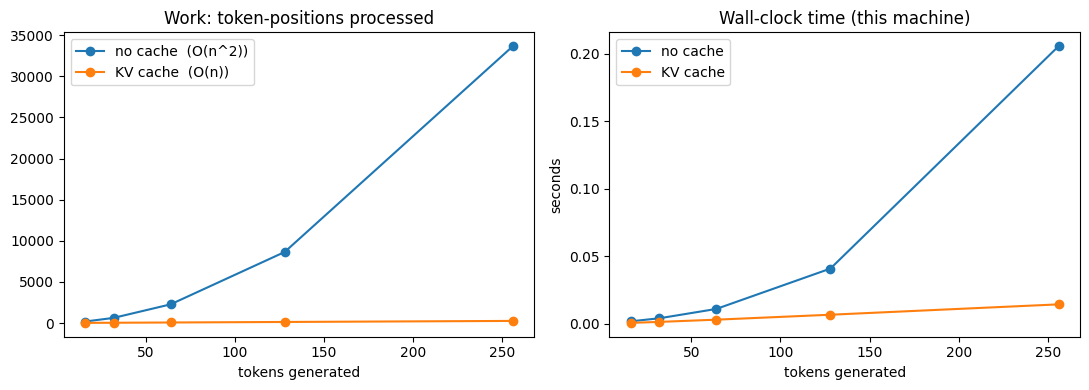

In [4]:
lengths = [16, 32, 64, 128, 256]
rows = []

for n_new in lengths:
    t0 = time.perf_counter()
    _, w_slow = generate_no_cache(prompt, model, n_new)
    t_slow = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, w_fast = generate_with_cache(prompt, model, n_new)
    t_fast = time.perf_counter() - t0

    rows.append((n_new, w_slow, w_fast, t_slow, t_fast))
    print(f"{n_new:4d} new tokens | work {w_slow:7d} vs {w_fast:5d} "
          f"| time {t_slow:6.3f}s vs {t_fast:6.3f}s | {t_slow / t_fast:4.1f}x faster")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lengths, [r[1] for r in rows], "o-", label="no cache  (O(n^2))")
axes[0].plot(lengths, [r[2] for r in rows], "o-", label="KV cache  (O(n))")
axes[0].set_title("Work: token-positions processed")
axes[0].set_xlabel("tokens generated")
axes[0].legend()

axes[1].plot(lengths, [r[3] for r in rows], "o-", label="no cache")
axes[1].plot(lengths, [r[4] for r in rows], "o-", label="KV cache")
axes[1].set_title("Wall-clock time (this machine)")
axes[1].set_xlabel("tokens generated")
axes[1].set_ylabel("seconds")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5 — The memory bill

The cache is not free. It sits in GPU memory and grows with **every token, for every user at the same time**:

```
KV bytes per token = 2 × layers × kv_heads × head_dim × bytes_per_number
                     ↑ one K + one V
```

Below: real model shapes. Note what GQA (8 KV heads instead of 32) does to the numbers, and note that the cache can easily outgrow the model weights themselves.

In [5]:
MODELS = {
    # name:                    (layers, kv_heads, head_dim, params_billion)
    "Llama-3-8B (GQA, 8 kv)":  (32, 8, 128, 8),
    "8B if it used MHA (32)":  (32, 32, 128, 8),
    "Llama-3-70B (GQA, 8 kv)": (80, 8, 128, 70),
}


def kv_bytes_per_token(layers, kv_heads, head_dim, bytes_per_number=2):
    return 2 * layers * kv_heads * head_dim * bytes_per_number


def weights_gb(params_billion, bytes_per_number=2):
    return params_billion * 1e9 * bytes_per_number / 1e9


GPU_GB = 80   # one H100

for name, (layers, kv_heads, head_dim, params_b) in MODELS.items():
    per_token = kv_bytes_per_token(layers, kv_heads, head_dim)
    w_gb = weights_gb(params_b)
    print(f"\n{name}")
    print(f"  weights (fp16): {w_gb:.0f} GB   |   KV cache: {per_token / 1024:.0f} KB per token")
    for ctx in (8_000, 32_000, 128_000):
        for users in (1, 32):
            cache_gb = per_token * ctx * users / 1e9
            total = w_gb + cache_gb
            verdict = "fits" if total < GPU_GB else "DOES NOT FIT"
            print(f"    {ctx // 1000:4d}k ctx x {users:3d} users -> cache {cache_gb:7.1f} GB"
                  f" | total {total:7.1f} GB on one {GPU_GB} GB GPU: {verdict}")


Llama-3-8B (GQA, 8 kv)
  weights (fp16): 16 GB   |   KV cache: 128 KB per token
       8k ctx x   1 users -> cache     1.0 GB | total    17.0 GB on one 80 GB GPU: fits
       8k ctx x  32 users -> cache    33.6 GB | total    49.6 GB on one 80 GB GPU: fits
      32k ctx x   1 users -> cache     4.2 GB | total    20.2 GB on one 80 GB GPU: fits
      32k ctx x  32 users -> cache   134.2 GB | total   150.2 GB on one 80 GB GPU: DOES NOT FIT
     128k ctx x   1 users -> cache    16.8 GB | total    32.8 GB on one 80 GB GPU: fits
     128k ctx x  32 users -> cache   536.9 GB | total   552.9 GB on one 80 GB GPU: DOES NOT FIT

8B if it used MHA (32)
  weights (fp16): 16 GB   |   KV cache: 512 KB per token
       8k ctx x   1 users -> cache     4.2 GB | total    20.2 GB on one 80 GB GPU: fits
       8k ctx x  32 users -> cache   134.2 GB | total   150.2 GB on one 80 GB GPU: DOES NOT FIT
      32k ctx x   1 users -> cache    16.8 GB | total    32.8 GB on one 80 GB GPU: fits
      32k ctx x  32 us

## Step 6 — TTFT and TPOT: where the time actually goes

Two phases, two different bottlenecks:

- **Prefill** reads your whole prompt in one parallel pass. It is compute-bound and it sets **TTFT** (time to first token).
- **Decode** writes one token per step, reading the whole model out of memory each time. It is memory-bound and it sets **TPOT** (time per output token).

The simple model below uses two made-up-but-realistic rates for an 8B model on one modern GPU. Change them to your own measurements later — the *shape* of the answer is what matters.

In [6]:
PREFILL_TOKENS_PER_SEC = 20_000   # prompt tokens read per second (compute-bound, parallel)
DECODE_TOKENS_PER_SEC = 50       # answer tokens written per second (memory-bound, one at a time)

CASES = [
    ("short chat",           200,  150),
    ("long doc summary",  50_000,  300),
    ("RAG answer",         5_000,  400),
    ("code generation",    2_000, 2_000),
]

print(f"{'case':20s} {'prompt':>8s} {'output':>8s} {'TTFT':>8s} {'TPOT':>8s} {'total':>8s}")
for name, prompt_tokens, output_tokens in CASES:
    ttft = prompt_tokens / PREFILL_TOKENS_PER_SEC
    tpot = 1 / DECODE_TOKENS_PER_SEC
    total = ttft + output_tokens * tpot
    print(f"{name:20s} {prompt_tokens:8d} {output_tokens:8d} "
          f"{ttft:7.2f}s {tpot * 1000:6.0f}ms {total:7.1f}s")

print("\nRead the table, not the numbers:")
print("  * TTFT is set by the PROMPT length. A 50k-token prompt makes the user wait before anything appears.")
print("  * TPOT never changes with prompt length - it depends on the model and the memory speed.")
print("  * Total time is dominated by OUTPUT length. This is why 'think step by step' everywhere is expensive.")

case                   prompt   output     TTFT     TPOT    total
short chat                200      150    0.01s     20ms     3.0s
long doc summary        50000      300    2.50s     20ms     8.5s
RAG answer               5000      400    0.25s     20ms     8.2s
code generation          2000     2000    0.10s     20ms    40.1s

Read the table, not the numbers:
  * TTFT is set by the PROMPT length. A 50k-token prompt makes the user wait before anything appears.
  * TPOT never changes with prompt length - it depends on the model and the memory speed.
  * Total time is dominated by OUTPUT length. This is why 'think step by step' everywhere is expensive.


## Step 7 — Prefix caching: the free win

Twenty users send the same 2,000-token system prompt. Without prefix caching you prefill those 2,000 tokens twenty times. With it, you prefill once and reuse the cached Keys and Values.

The catch, and the design rule: caching only works on a shared **prefix**. Put the long unchanging part *first*, and the user's changing text *last*. Reverse that order and every request pays full price.

In [7]:
SYSTEM_PROMPT_TOKENS = 2_000
USER_TOKENS = 100
REQUESTS = 20

no_cache = REQUESTS * (SYSTEM_PROMPT_TOKENS + USER_TOKENS)
with_cache = SYSTEM_PROMPT_TOKENS + REQUESTS * USER_TOKENS   # prefix prefilled once

print(f"prompt tokens prefilled, no prefix cache : {no_cache:,}")
print(f"prompt tokens prefilled, with prefix cache: {with_cache:,}")
print(f"saved: {(1 - with_cache / no_cache) * 100:.0f}% of prefill work and input cost")

print("\nAnd if you put the user's text FIRST, the shared prefix is only")
print("as long as the part they happen to have in common - usually nothing.")

prompt tokens prefilled, no prefix cache : 42,000
prompt tokens prefilled, with prefix cache: 4,000
saved: 90% of prefill work and input cost

And if you put the user's text FIRST, the shared prefix is only
as long as the part they happen to have in common - usually nothing.


## Your turn — modify and debug on purpose

Guess first, then run.

1. In Step 3, delete the two `K_cache`/`V_cache` append lines and keep only the newest token's K and V. The code still runs — what breaks in the output, and why does the `assert` catch it?
2. In Step 3, change `pos = len(tokens) - 1` to `pos = len(tokens)` — an off-by-one on the position. Does the `assert` still pass? This is the most common KV-cache bug in real code, and it is silent: the model keeps producing fluent text that is subtly wrong.
3. In Step 5, add a `Llama-3-70B at 4-bit weights with an FP8 KV cache` row (weights `0.5 ×`, cache bytes_per_number `1`). Which lever helped more — quantizing the weights, or quantizing the cache? Does the answer change at 128k context?
4. In Step 6, set `DECODE_TOKENS_PER_SEC = 200` (a smaller model). Which case improves most, and which barely moves? What does that tell you about when a bigger model is affordable?
5. In Step 6, add a "reasoning model" case with 1,000 prompt tokens and 8,000 output tokens (most of them thinking tokens the user never sees). Compare the total time to "short chat".
6. Without AI help, answer in your own words: *you serve a 70B model at 100k context with batch size 32 and it runs out of memory. Name three different fixes, and what each one costs you.*